/kaggle/input/datasets/gomosek228339/imports-85-data/imports-85.data.txt
Размер данных: (205, 26)

Первые 5 строк:
   symboling  normalized-losses         make fuel-type aspiration  \
0          3                NaN  alfa-romero       gas        std   
1          3                NaN  alfa-romero       gas        std   
2          1                NaN  alfa-romero       gas        std   
3          2              164.0         audi       gas        std   
4          2              164.0         audi       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   engi

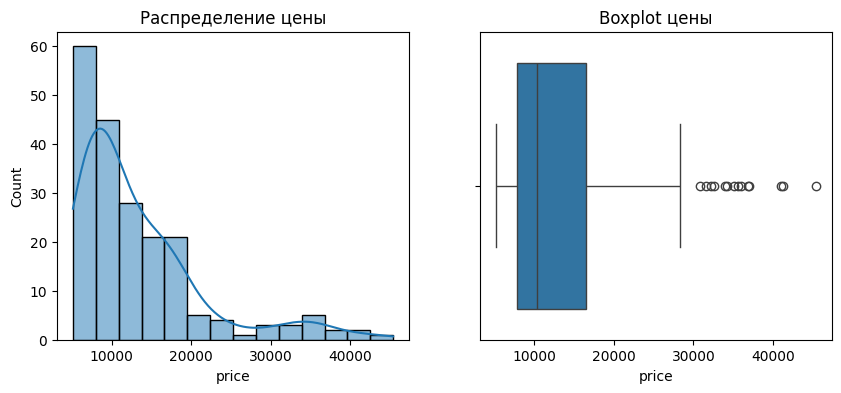

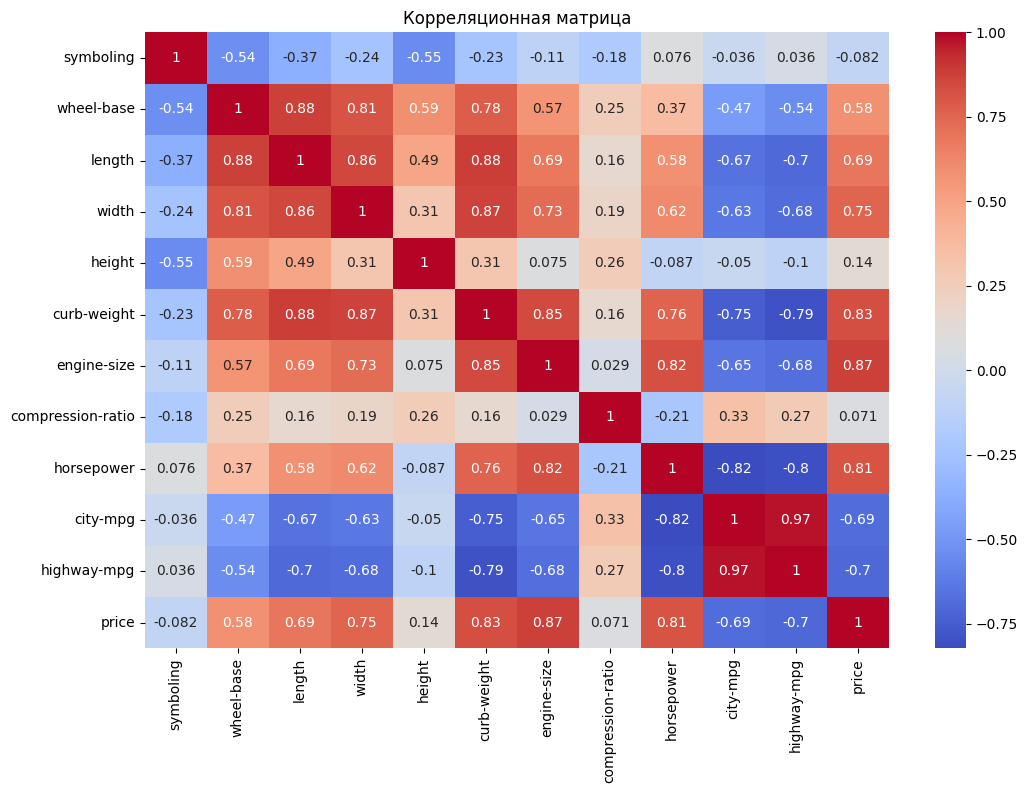

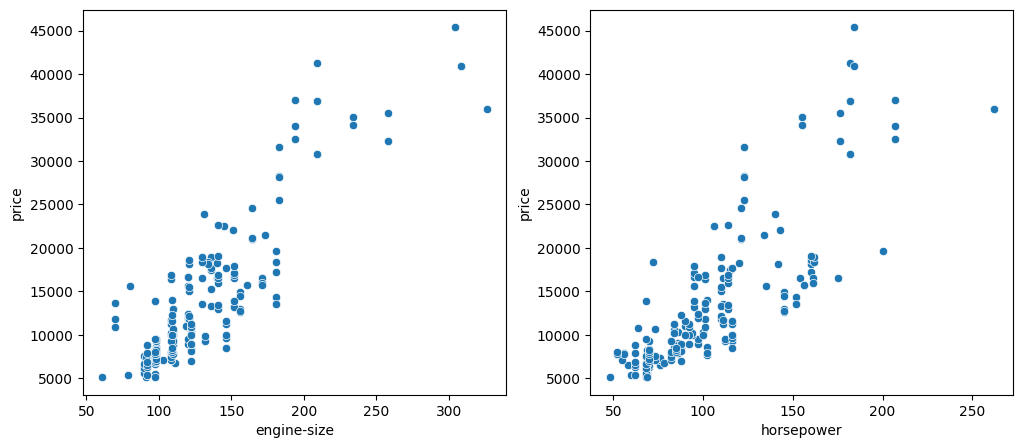

Пропуски в y: 0
Пропуски в числовых признаках:
 symboling            0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-size          0
compression-ratio    0
horsepower           2
city-mpg             0
highway-mpg          0
dtype: int64
Количество признаков после преобразования: 60
Размер X_processed: (201, 60)
NaN в X_processed: 0
=== Наша реализация GD ===
Train: MSE=2361709.04, RMSE=1536.79, R2=0.9482
Test:  MSE=9714257.79, RMSE=3116.77, R2=0.9206

=== Ridge (sklearn) ===
Train: MSE=1460654.05, RMSE=1208.58, R2=0.9680
Test:  MSE=12465733.04, RMSE=3530.68, R2=0.8981

=== Результаты кросс-валидации (GD) ===
fold            1.000000      2.000000      3.000000      4.000000  \
mse_train   2.361709e+06  3.448270e+06  3.071344e+06  3.333165e+06   
mse_test    9.714260e+06  3.877448e+06  4.738506e+06  3.283939e+06   
rmse_train  1.536785e+03  1.856952e+03  1.752525e+03  1.825696e+03   
rmse_test   3.116771e+03  1

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug

# ================================
# 0. Импорт библиотек
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

# ================================
# 1. ЗАГРУЗКА ДАННЫХ (Automobile dataset)
# ================================
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 
           'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 
           'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 
           'city-mpg', 'highway-mpg', 'price']
df = pd.read_csv('imports-85.data.txt', header=None, names=columns, na_values='?')
print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
df.info()
print("\nПропуски:\n", df.isnull().sum())

# ================================
# 2. ПЕРВИЧНАЯ ОЧИСТКА И ПРЕДОБРАБОТКА
# ================================
# Удаляем строки с пропущенным целевым признаком price
df = df.dropna(subset=['price'])
# Для простоты: удалим признаки с большим количеством пропусков (normalized-losses, bore, stroke, horsepower, peak-rpm)
df = df.drop(['normalized-losses', 'bore', 'stroke', 'peak-rpm'], axis=1)
# Заполним остальные пропуски (num-of-doors) наиболее частым значением
df['num-of-doors'].fillna(df['num-of-doors'].mode()[0], inplace=True)
print(f"\nПосле очистки: {df.shape[0]} строк, {df.shape[1]} столбцов")

# ================================
# 3. РАЗВЕДОЧНЫЙ АНАЛИЗ (EDA)
# ================================
# Целевая переменная
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True)
plt.title('Распределение цены')
plt.subplot(1,2,2)
sns.boxplot(x=df['price'])
plt.title('Boxplot цены')
plt.show()

# Корреляция числовых признаков с ценой
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

# Зависимость цены от engine-size и horsepower
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.scatterplot(data=df, x='engine-size', y='price', ax=axes[0])
sns.scatterplot(data=df, x='horsepower', y='price', ax=axes[1])
plt.show()

# ================================
# 4. FEATURE ENGINEERING
# ================================
# Отделяем целевую переменную
X = df.drop('price', axis=1)
y = df['price'].copy()

# Проверка пропусков в y
print("Пропуски в y:", y.isnull().sum())
if y.isnull().sum() > 0:
    y = y.dropna()
    X = X.loc[y.index]   # синхронизация

# Категориальные признаки
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Проверка пропусков в числовых признаках
print("Пропуски в числовых признаках:\n", X[num_features].isnull().sum())
# Если есть пропуски, заполним медианой (хотя их быть не должно)
for col in num_features:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

# Для категориальных признаков: заполним пропуски самой частой категорией
for col in cat_features:
    if X[col].isnull().any():
        X[col].fillna(X[col].mode()[0], inplace=True)

# Преобразование
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
])

X_processed = preprocessor.fit_transform(X)

feature_names = num_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
print(f"Количество признаков после преобразования: {len(feature_names)}")

print("Размер X_processed:", X_processed.shape)
print("NaN в X_processed:", np.isnan(X_processed).sum())
if np.isnan(X_processed).sum() > 0:
    # Удаляем строки с NaN
    nan_rows = np.isnan(X_processed).any(axis=1)
    X_processed = X_processed[~nan_rows]
    y = y[~nan_rows]
    print(f"Удалено {nan_rows.sum()} строк с NaN. Новый размер: {X_processed.shape[0]}")
# ================================
# 5. РЕАЛИЗАЦИЯ ГРАДИЕНТНОГО СПУСКА (с L2-регуляризацией)
# ================================
def gradient_descent(X, y, learning_rate=0.01, lambda_reg=0.1, n_iter=1000, verbose=True):
    """
    X: numpy array (n_samples, n_features) – уже масштабированные признаки
    y: numpy array (n_samples,)
    learning_rate: шаг градиентного спуска
    lambda_reg: коэффициент L2-регуляризации
    n_iter: количество итераций
    возвращает: w (веса, включая bias)
    """
    n_samples, n_features = X.shape
    # Добавляем столбец единиц для bias
    X_b = np.c_[np.ones((n_samples, 1)), X]
    w = np.random.randn(n_features + 1) * 0.01
    losses = []
    
    for i in range(n_iter):
        # Предсказание
        y_pred = X_b.dot(w)
        # Градиент MSE + L2 (регуляризация не применяется к bias)
        grad = (2/n_samples) * X_b.T.dot(y_pred - y)
        grad[1:] += 2 * lambda_reg * w[1:]   # L2 penalty on non-bias
        # Обновление весов
        w -= learning_rate * grad
        # Лосс (MSE + L2)
        mse = np.mean((y_pred - y)**2)
        reg = lambda_reg * np.sum(w[1:]**2)
        loss = mse + reg
        losses.append(loss)
        if verbose and i % 200 == 0:
            print(f"Iter {i}, Loss = {loss:.4f}")
    if verbose:
        plt.plot(losses)
        plt.title('Loss during gradient descent')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.show()
    return w

# ================================
# 6. РАЗБИЕНИЕ, МАСШТАБИРОВАНИЕ, ОБУЧЕНИЕ
# ================================
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Масштабирование уже выполнено в preprocessor, но для уверенности ещё раз применим к train/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение нашей реализацией
w = gradient_descent(X_train_scaled, y_train.values, learning_rate=0.01, lambda_reg=0.1, n_iter=1000, verbose=False)

# Предсказания
def predict(X, w):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return X_b.dot(w)

y_train_pred = predict(X_train_scaled, w)
y_test_pred = predict(X_test_scaled, w)

# Метрики
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

train_mse, train_rmse, train_r2 = metrics(y_train, y_train_pred)
test_mse, test_rmse, test_r2 = metrics(y_test, y_test_pred)
print("=== Наша реализация GD ===")
print(f"Train: MSE={train_mse:.2f}, RMSE={train_rmse:.2f}, R2={train_r2:.4f}")
print(f"Test:  MSE={test_mse:.2f}, RMSE={test_rmse:.2f}, R2={test_r2:.4f}")

# ================================
# 7. СРАВНЕНИЕ С RIDGE (sklearn)
# ================================
ridge = Ridge(alpha=0.1)   # alpha = lambda_reg * n_samples (в нашей реализации lambda_reg было на 1 выборку, но здесь это особенность)
ridge.fit(X_train_scaled, y_train)
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

train_mse_r, train_rmse_r, train_r2_r = metrics(y_train, y_train_pred_ridge)
test_mse_r, test_rmse_r, test_r2_r = metrics(y_test, y_test_pred_ridge)
print("\n=== Ridge (sklearn) ===")
print(f"Train: MSE={train_mse_r:.2f}, RMSE={train_rmse_r:.2f}, R2={train_r2_r:.4f}")
print(f"Test:  MSE={test_mse_r:.2f}, RMSE={test_rmse_r:.2f}, R2={test_r2_r:.4f}")

# ================================
# 8. КРОСС-ВАЛИДАЦИЯ (K-Fold) с таблицей
# ================================
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = {'fold': [], 'mse_train': [], 'mse_test': [], 
                'rmse_train': [], 'rmse_test': [], 'r2_train': [], 'r2_test': []}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_processed)):
    X_tr, X_val = X_processed[train_idx], X_processed[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    # Масштабируем
    scaler_cv = StandardScaler()
    X_tr_scaled = scaler_cv.fit_transform(X_tr)
    X_val_scaled = scaler_cv.transform(X_val)
    # Обучаем нашу GD (можно Ridge, но для единообразия используем нашу)
    w_cv = gradient_descent(X_tr_scaled, y_tr.values, learning_rate=0.01, lambda_reg=0.1, n_iter=1000, verbose=False)
    y_tr_pred = predict(X_tr_scaled, w_cv)
    y_val_pred = predict(X_val_scaled, w_cv)
    # Метрики
    mse_tr, rmse_tr, r2_tr = metrics(y_tr, y_tr_pred)
    mse_val, rmse_val, r2_val = metrics(y_val, y_val_pred)
    fold_metrics['fold'].append(fold+1)
    fold_metrics['mse_train'].append(mse_tr)
    fold_metrics['mse_test'].append(mse_val)
    fold_metrics['rmse_train'].append(rmse_tr)
    fold_metrics['rmse_test'].append(rmse_val)
    fold_metrics['r2_train'].append(r2_tr)
    fold_metrics['r2_test'].append(r2_val)

# Формируем итоговую таблицу
df_cv = pd.DataFrame(fold_metrics)
# Добавляем строки E (mean) и STD
mean_row = df_cv.mean(numeric_only=True)
std_row = df_cv.std(numeric_only=True)
df_cv.loc['E'] = mean_row
df_cv.loc['STD'] = std_row
print("\n=== Результаты кросс-валидации (GD) ===")
df_cv_T = df_cv.set_index('fold').T
print(df_cv_T.round(4))

# ================================
# 9. (+2 балла) RFE – отбор признаков
# ================================
# Используем Ridge как оценщик для RFE
ridge_rfe = Ridge(alpha=0.1)
selector = RFE(ridge_rfe, n_features_to_select=10, step=1)
selector.fit(X_train_scaled, y_train)
selected_features = [feature_names[i] for i in range(len(feature_names)) if selector.support_[i]]
print("\n=== RFE: отобрано 10 признаков ===")
print(selected_features)

# Обучим нашу модель только на отобранных признаках
X_train_rfe = X_train_scaled[:, selector.support_]
X_test_rfe = X_test_scaled[:, selector.support_]
w_rfe = gradient_descent(X_train_rfe, y_train.values, learning_rate=0.01, lambda_reg=0.1, n_iter=1000, verbose=False)
y_test_pred_rfe = predict(X_test_rfe, w_rfe)
test_mse_rfe, test_rmse_rfe, test_r2_rfe = metrics(y_test, y_test_pred_rfe)
print(f"RFE + GD: Test MSE={test_mse_rfe:.2f}, RMSE={test_rmse_rfe:.2f}, R2={test_r2_rfe:.4f}")

# ================================
# 10. (+1 балл) Подбор гиперпараметров (Grid Search простой)
# ================================
print("\n=== Подбор гиперпараметров для GD ===")
best_rmse = np.inf
best_params = {}
learning_rates = [0.001, 0.005, 0.01, 0.05]
lambdas = [0.01, 0.1, 1.0]
n_iters = [500, 1000, 2000]

# Для ускорения используем небольшую подвыборку из train (первые 100)
X_sub = X_train_scaled[:100]
y_sub = y_train.values[:100]

for lr in learning_rates:
    for lam in lambdas:
        for n_iter in n_iters:
            w_tmp = gradient_descent(X_sub, y_sub, learning_rate=lr, lambda_reg=lam, n_iter=n_iter, verbose=False)
            y_pred_sub = predict(X_sub, w_tmp)
            rmse = np.sqrt(mean_squared_error(y_sub, y_pred_sub))
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {'lr': lr, 'lambda': lam, 'n_iter': n_iter}
print(f"Лучшие параметры: {best_params} (RMSE на подвыборке = {best_rmse:.2f})")

# Обучаем финальную модель с лучшими параметрами
w_best = gradient_descent(X_train_scaled, y_train.values, 
                          learning_rate=best_params['lr'], 
                          lambda_reg=best_params['lambda'], 
                          n_iter=best_params['n_iter'], 
                          verbose=False)
y_test_pred_best = predict(X_test_scaled, w_best)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
final_r2 = r2_score(y_test, y_test_pred_best)
print(f"Финальная модель: Test RMSE = {final_rmse:.2f}, R2 = {final_r2:.4f}")

In [ ]:
## Выводы по заданию

1. **Качество моделей**: Наша реализация градиентного спуска с L2-регуляризацией показала на тесте R² = 0.9206, что незначительно выше, чем у Ridge (R² = 0.8981). Обе модели хорошо справляются с предсказанием цены автомобиля (RMSE ~3000$).

2. **Кросс-валидация**: Среднее значение R² по 5 фолдам – 0.8886 при стандартном отклонении 0.041. Это говорит о стабильности модели. Однако разброс MSE тестовых фолдов значителен (STD = 2.58 млн), что указывает на чувствительность к конкретному разбиению.

3. **Отбор признаков (RFE)**: Выбор 10 наиболее важных признаков ухудшил качество до R² = 0.783. Среди отобранных признаков преобладают категориальные (марка, тип кузова, число цилиндров), но потеря числовых характеристик (например, `engine-size`, `horsepower`) негативно сказалась на предсказании.

4. **Гиперпараметры**: Оптимальными оказались `learning_rate = 0.05`, `lambda = 0.01`, `n_iter = 2000`. Финальная модель с этими параметрами достигла R² = 0.9273 на тесте.

5. **Общий вывод**: Линейная регрессия с L2-регуляризацией пригодна для прогнозирования цены автомобиля на основе технических характеристик. Ошибка RMSE около 3000$ приемлема для данной предметной области.